In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

In [3]:
df = pd.read_csv("startup_funding_cleaned(1).csv")

In [4]:
df.head()

df.tail()

df.sample(5)

,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD
500,500,2016-12-23,enKast,Technology,Cloud based CRM for Agencies,Bangalore,Ivy League Alumni Angel Network,Private Equity,2000000.0
362,362,2017-02-22,Vebbler,Consumer Internet,Photo Sharing for Groups,Bangalore,Facebook FBStart,Seed Funding,40000.0
1318,1318,2016-02-24,LoanZen,Consumer Internet,Peer to peer Lending marketplace,Bangalore,Tracxn Syndicate,Seed Funding,NaN
701,701,2016-09-15,infeedo,Consumer Internet,Employee engagement platform,Gurgaon,"Dheeraj Jain, Palash Jain, Anupam Mittal, Amee...",Seed Funding,200000.0
1918,1918,2015-07-07,IndiaLends,Financial Tech,NaN,New Delhi,"DSG Consumer Partners, Siddharth Parekh",Private Equity,NaN


In [5]:
print("Rows and Columns :", df.shape)

df.info()

df.describe()

Rows and Columns : (2372, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SNo               2372 non-null   int64  
 1   Date              2367 non-null   object 
 2   StartupName       2372 non-null   object 
 3   IndustryVertical  2201 non-null   object 
 4   SubVertical       1436 non-null   object 
 5   CityLocation      2193 non-null   object 
 6   InvestorsName     2364 non-null   object 
 7   InvestmentType    2371 non-null   object 
 8   AmountInUSD       1525 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 166.9+ KB


,SNo,AmountInUSD
count,2372.000000,1.525000e+03
mean,1185.500000,1.203107e+07
std,684.881742,6.403118e+07
min,0.000000,1.600000e+04
25%,592.750000,3.700000e+05
50%,1185.500000,1.070000e+06
75%,1778.250000,6.000000e+06
max,2371.000000,1.400000e+09


In [6]:
df.isnull().sum()

,0
SNo,0
Date,5
StartupName,0
IndustryVertical,171
SubVertical,936
CityLocation,179
InvestorsName,8
InvestmentType,1
AmountInUSD,847


In [7]:
print(df.duplicated().sum())

0


In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

df["Quarter"] = df["Date"].dt.quarter

In [9]:
print("Total Funding :", df["AmountInUSD"].sum())

Total Funding : 18347386476.0


In [10]:
print("Average Funding :", round(df["AmountInUSD"].mean(),2))

Average Funding : 12031073.1


In [11]:
print(df["StartupName"].nunique())

2001


In [12]:
print(df["InvestorsName"].nunique())

1885


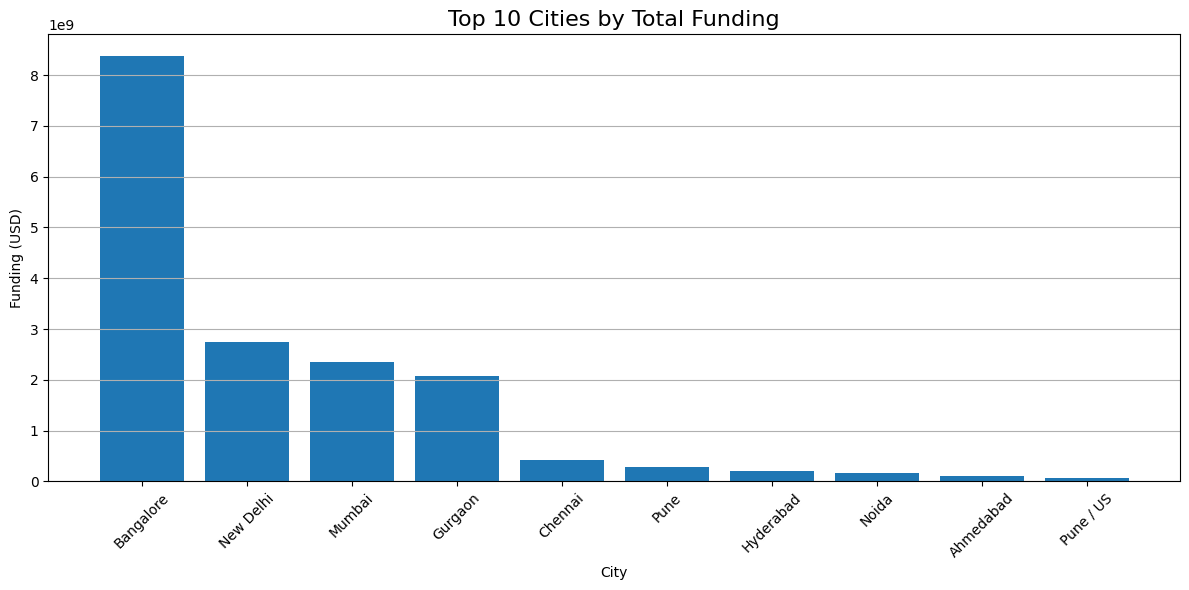

In [13]:
city = (
    df.groupby("CityLocation")["AmountInUSD"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(city.index, city.values)

plt.title("Top 10 Cities by Total Funding", fontsize=16)

plt.xlabel("City")

plt.ylabel("Funding (USD)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

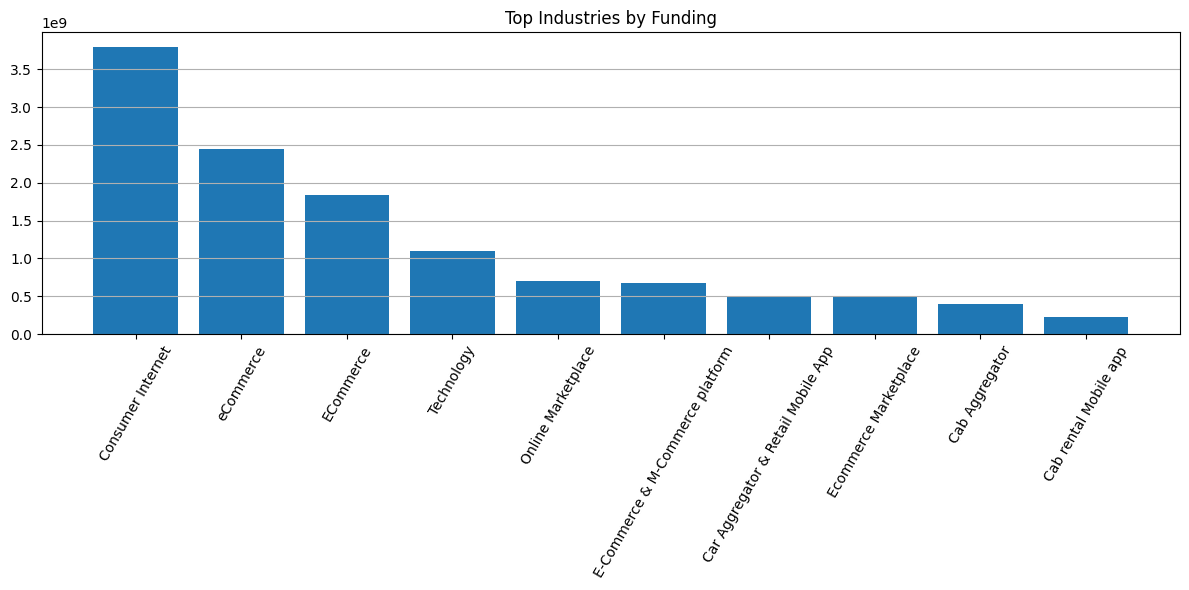

In [14]:
industry = (
    df.groupby("IndustryVertical")["AmountInUSD"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(industry.index, industry.values)

plt.title("Top Industries by Funding")

plt.xticks(rotation=60)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

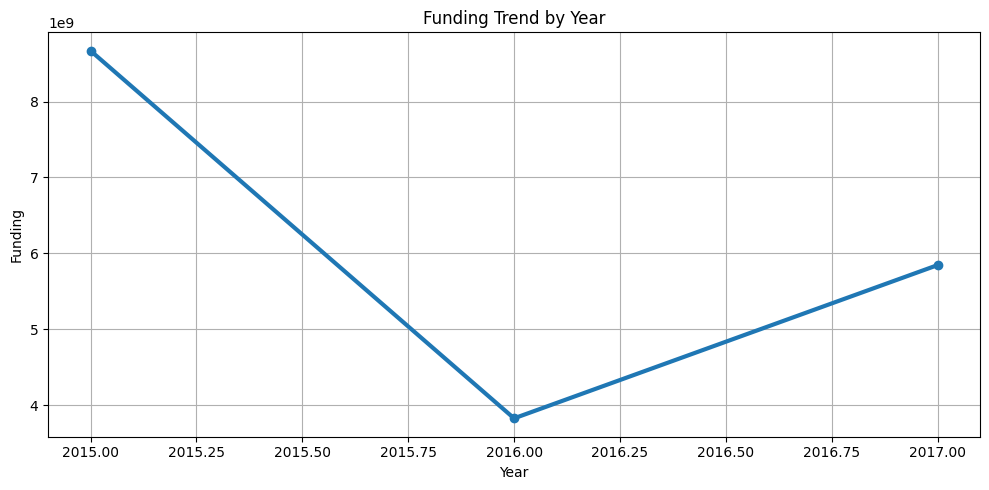

In [15]:
year = df.groupby("Year")["AmountInUSD"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    year.index,
    year.values,
    marker="o",
    linewidth=3
)

plt.title("Funding Trend by Year")

plt.xlabel("Year")

plt.ylabel("Funding")

plt.grid(True)

plt.tight_layout()

plt.show()

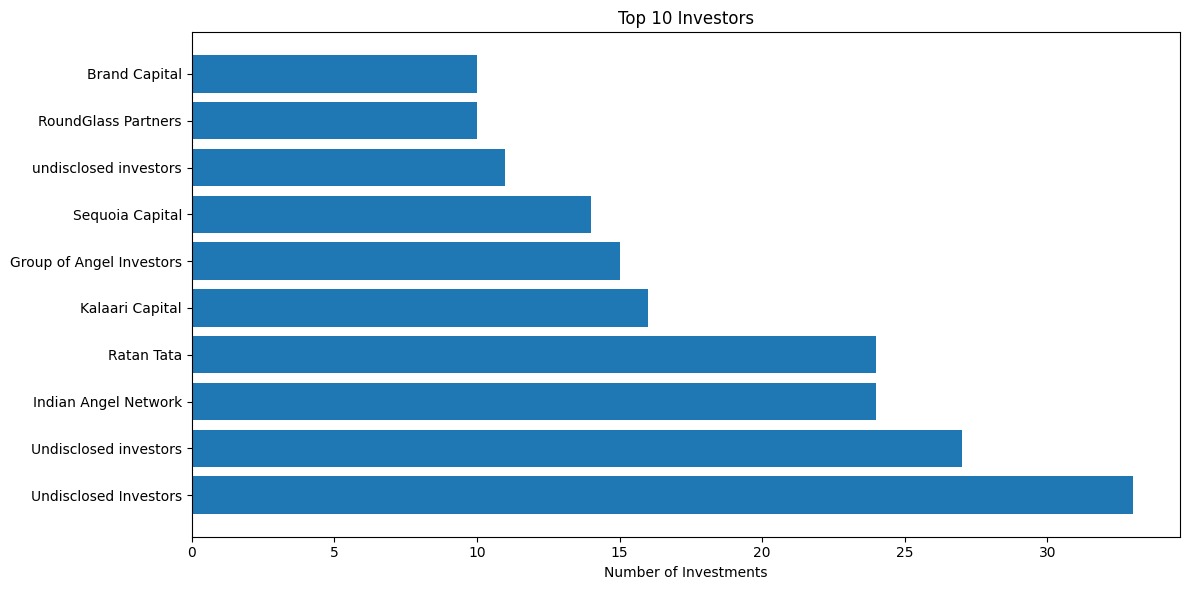

In [16]:
investor = df["InvestorsName"].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.barh(investor.index, investor.values)

plt.title("Top 10 Investors")

plt.xlabel("Number of Investments")

plt.tight_layout()

plt.show()

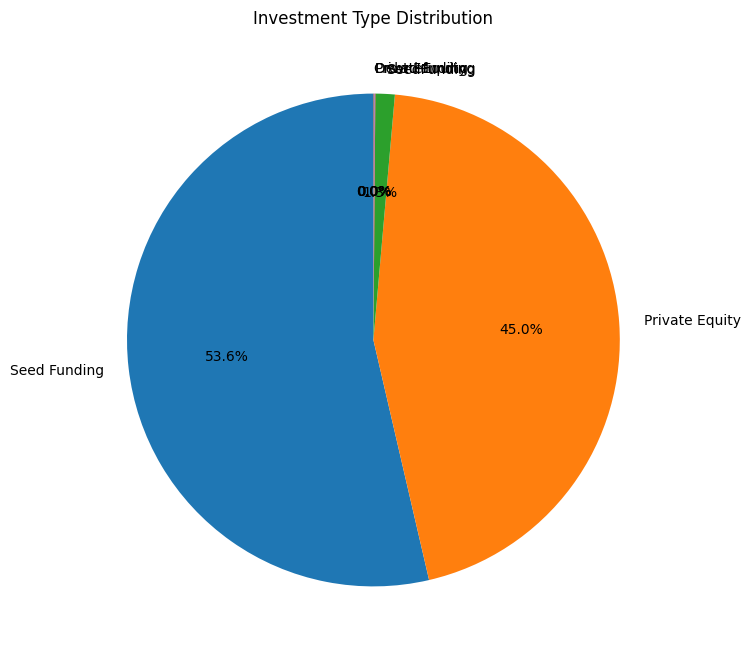

In [17]:
investment = df["InvestmentType"].value_counts().head(6)

plt.figure(figsize=(8,8))

plt.pie(
    investment.values,
    labels=investment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investment Type Distribution")

plt.show()

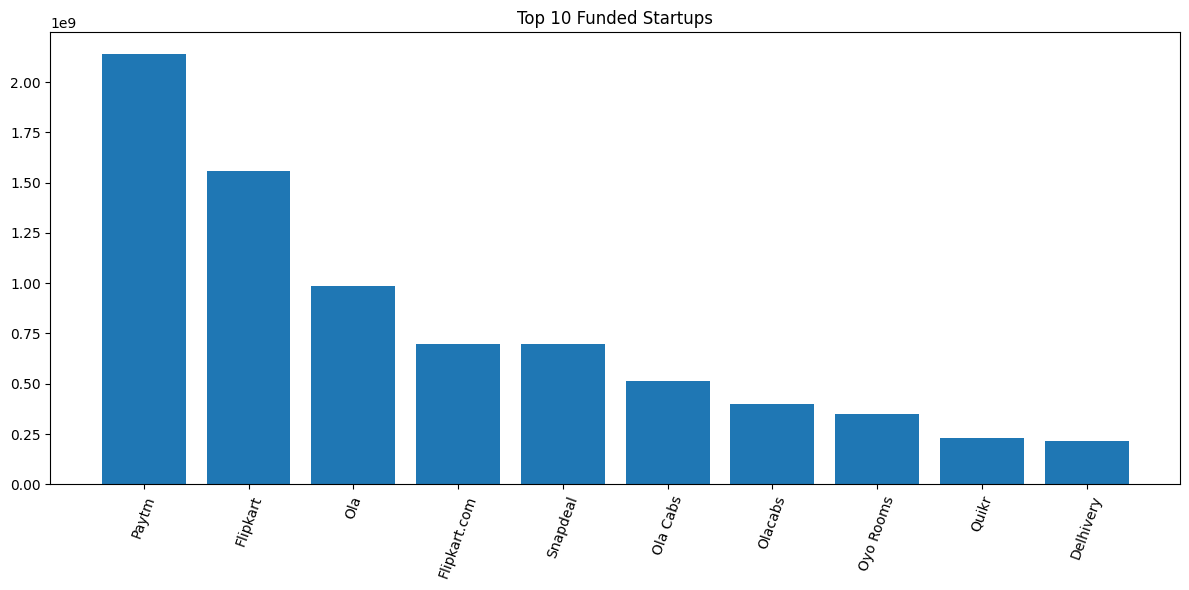

In [18]:
startup = (
    df.groupby("StartupName")["AmountInUSD"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(startup.index, startup.values)

plt.title("Top 10 Funded Startups")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

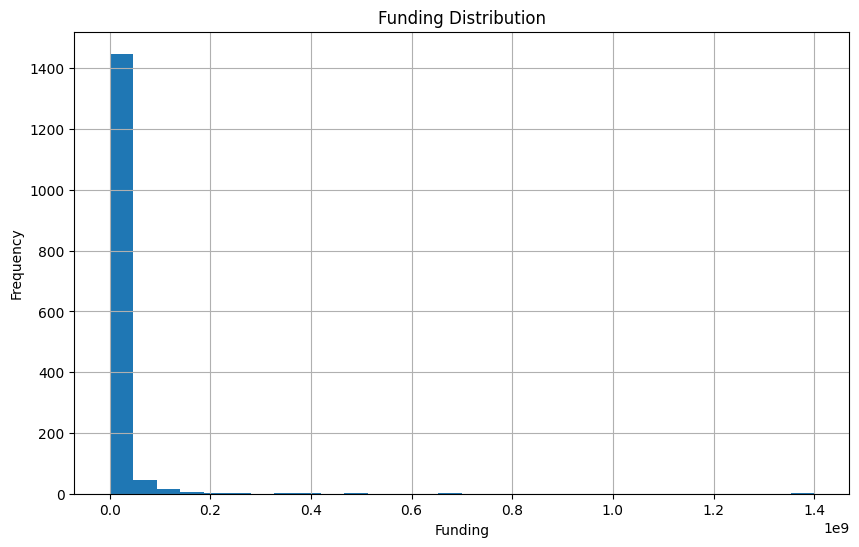

In [19]:
plt.figure(figsize=(10,6))

plt.hist(
    df["AmountInUSD"].dropna(),
    bins=30
)

plt.title("Funding Distribution")

plt.xlabel("Funding")

plt.ylabel("Frequency")

plt.grid()

plt.show()

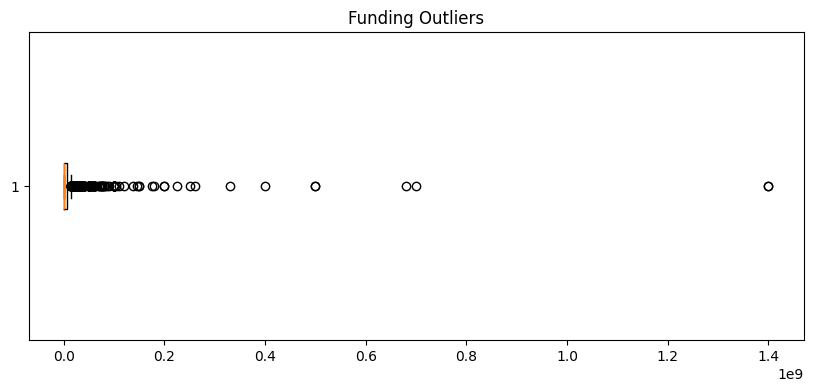

In [20]:
plt.figure(figsize=(10,4))

plt.boxplot(
    df["AmountInUSD"].dropna(),
    vert=False
)

plt.title("Funding Outliers")

plt.show()

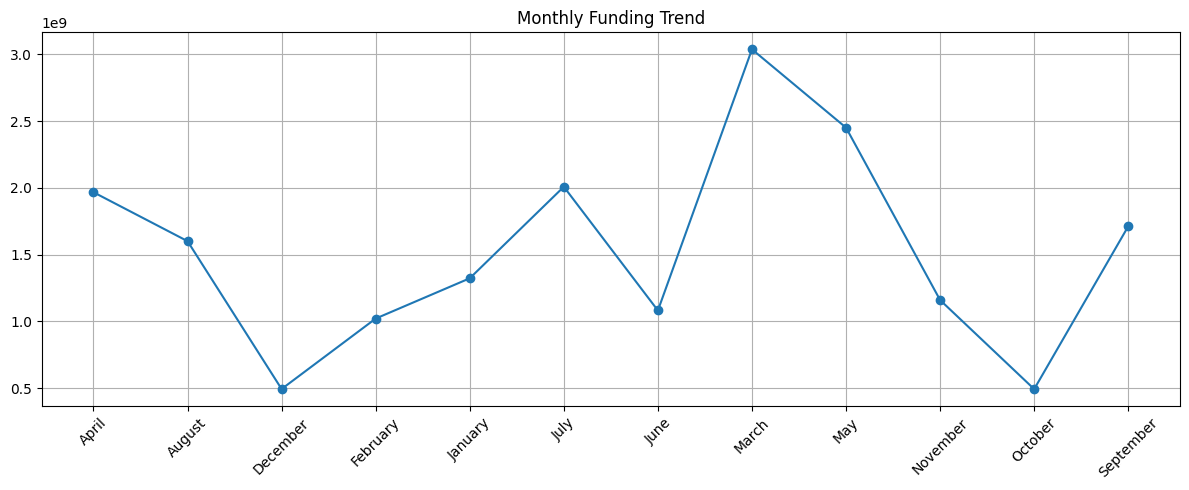

In [21]:
monthly = df.groupby("Month")["AmountInUSD"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Funding Trend")

plt.grid(True)

plt.tight_layout()

plt.show()

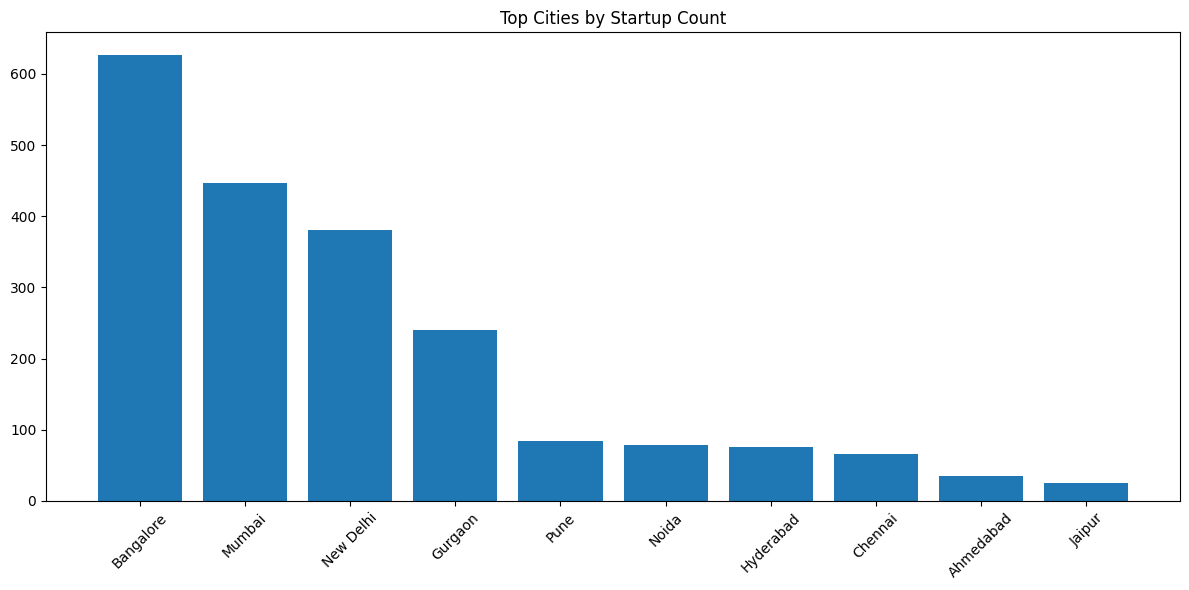

In [22]:
city_count = df["CityLocation"].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.bar(
    city_count.index,
    city_count.values
)

plt.title("Top Cities by Startup Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [23]:
print("========== KPI SUMMARY ==========")

print("Total Funding :", df["AmountInUSD"].sum())

print("Average Funding :", df["AmountInUSD"].mean())

print("Total Startups :", df["StartupName"].nunique())

print("Total Investors :", df["InvestorsName"].nunique())

print("Total Cities :", df["CityLocation"].nunique())

print("Total Industries :", df["IndustryVertical"].nunique())

========== KPI SUMMARY ==========
Total Funding : 18347386476.0
Average Funding : 12031073.099016393
Total Startups : 2001
Total Investors : 1885
Total Cities : 71
Total Industries : 743


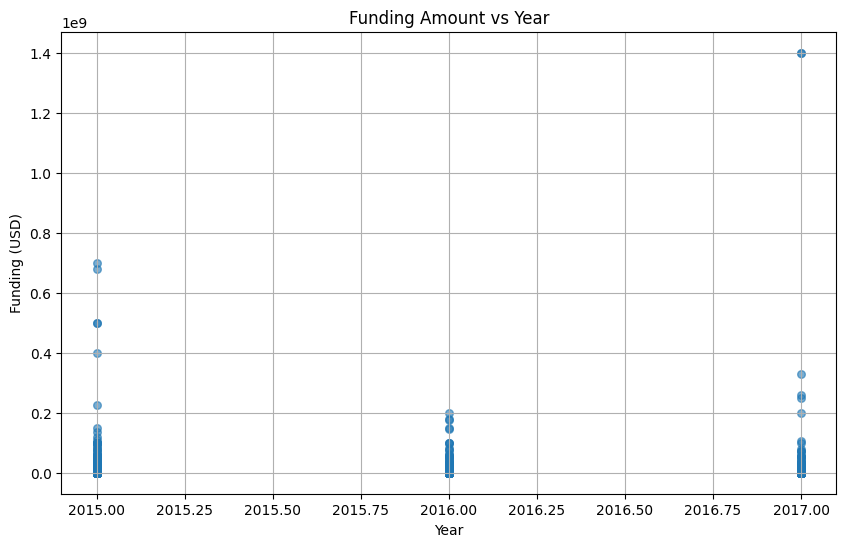

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Year"],
    df["AmountInUSD"],
    alpha=0.6,
    s=30
)

plt.title("Funding Amount vs Year")

plt.xlabel("Year")

plt.ylabel("Funding (USD)")

plt.grid(True)

plt.show()

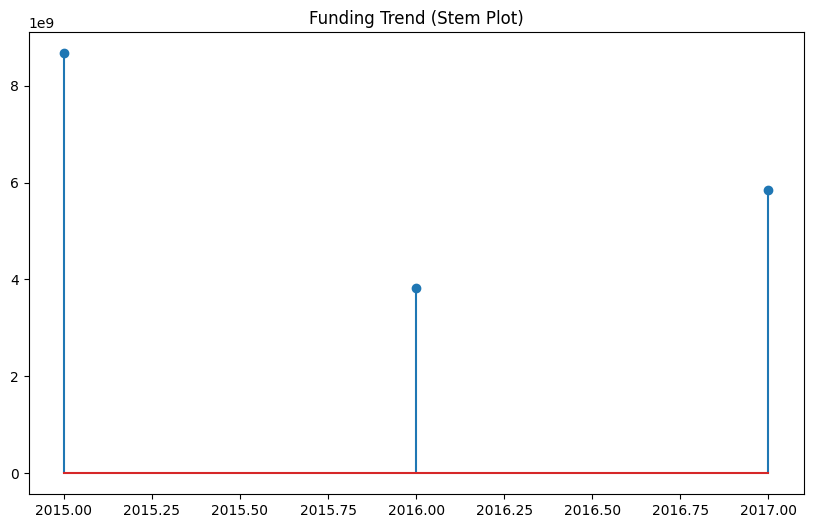

In [28]:
year = df.groupby("Year")["AmountInUSD"].sum()

plt.figure(figsize=(10,6))

markerline, stemlines, baseline = plt.stem(
    year.index,
    year.values
)

plt.title("Funding Trend (Stem Plot)")

plt.show()

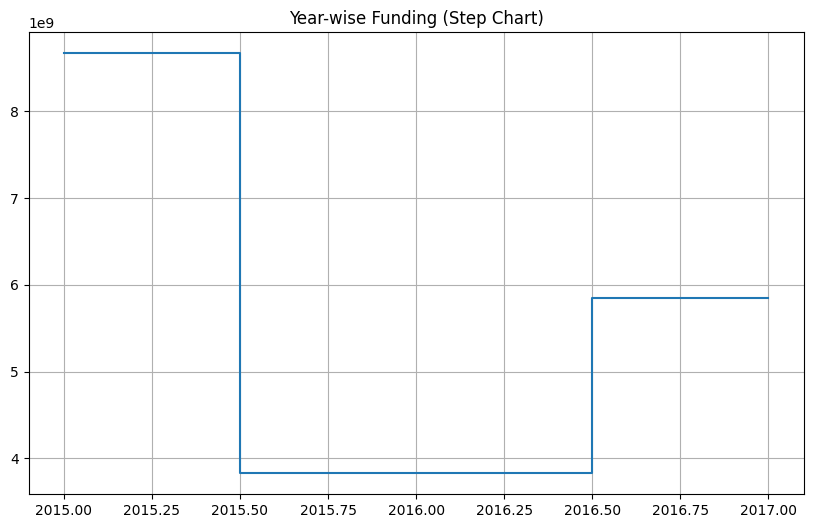

In [29]:
year = df.groupby("Year")["AmountInUSD"].sum()

plt.figure(figsize=(10,6))

plt.step(
    year.index,
    year.values,
    where="mid"
)

plt.title("Year-wise Funding (Step Chart)")

plt.grid()

plt.show()

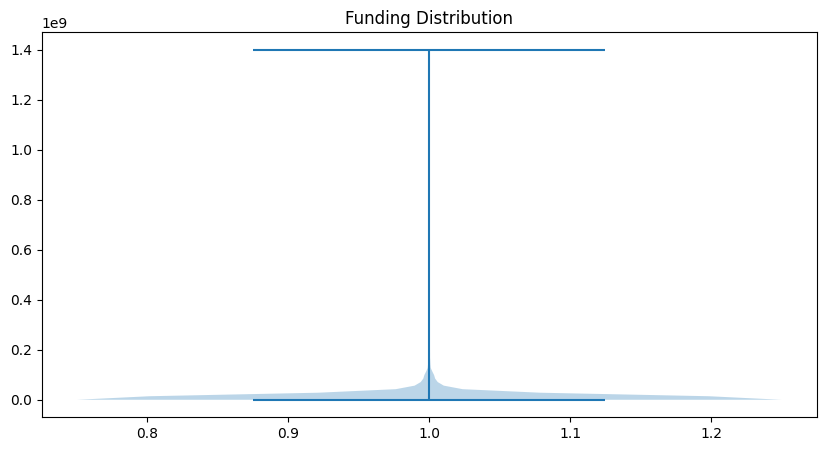

In [31]:
plt.figure(figsize=(10,5))

plt.violinplot(df["AmountInUSD"].dropna())

plt.title("Funding Distribution")

plt.show()

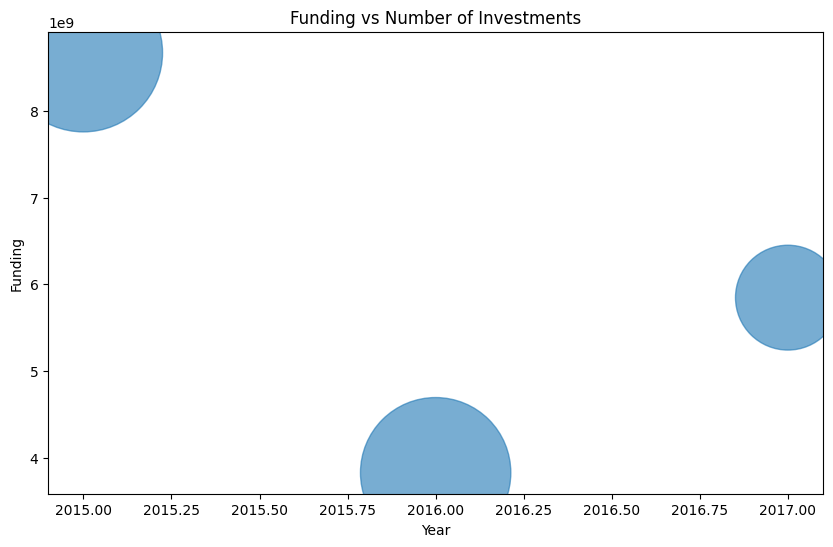

In [33]:
fund = df.groupby("Year")["AmountInUSD"].agg(["sum","count"])

plt.figure(figsize=(10,6))

plt.scatter(
    fund.index,
    fund["sum"],
    s=fund["count"]*20,
    alpha=0.6
)

plt.title("Funding vs Number of Investments")

plt.xlabel("Year")

plt.ylabel("Funding")

plt.show()

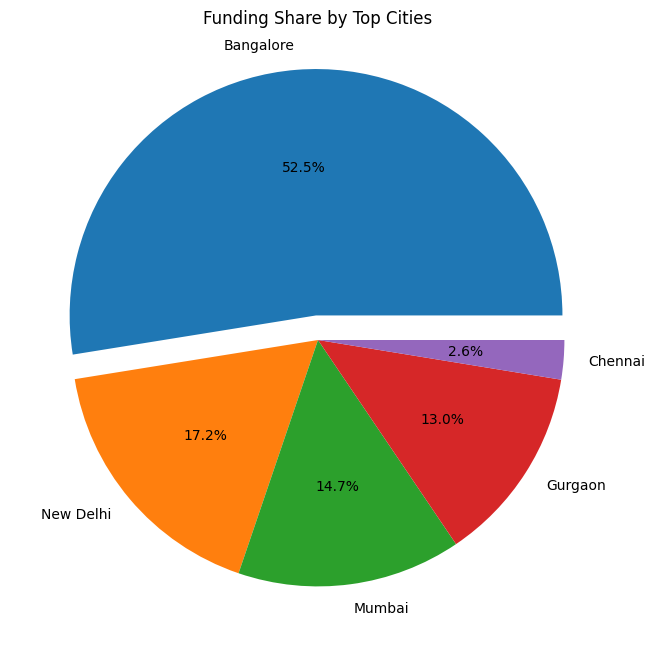

In [34]:
city = df.groupby("CityLocation")["AmountInUSD"].sum().nlargest(5)

plt.figure(figsize=(8,8))

plt.pie(
    city.values,
    labels=city.index,
    autopct="%1.1f%%",
    explode=[0.1,0,0,0,0]
)

plt.title("Funding Share by Top Cities")

plt.show()

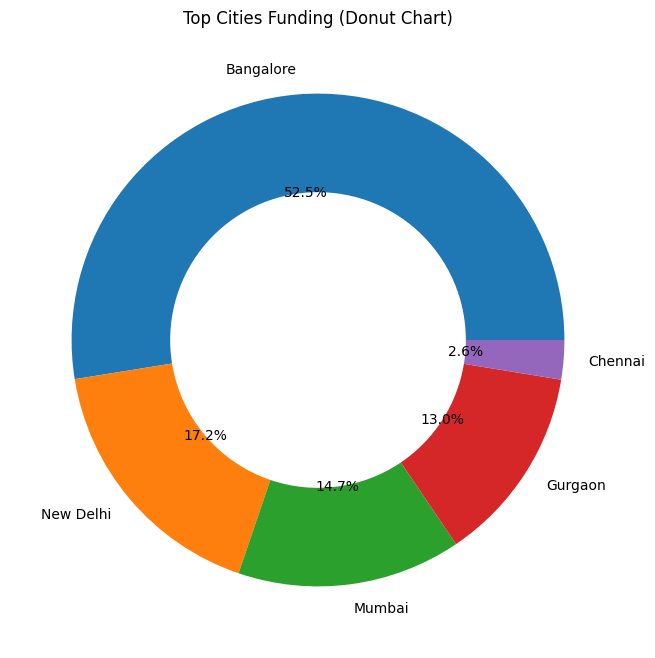

In [35]:
city = df.groupby("CityLocation")["AmountInUSD"].sum().nlargest(5)

plt.figure(figsize=(8,8))

plt.pie(
    city.values,
    labels=city.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Top Cities Funding (Donut Chart)")

plt.show()

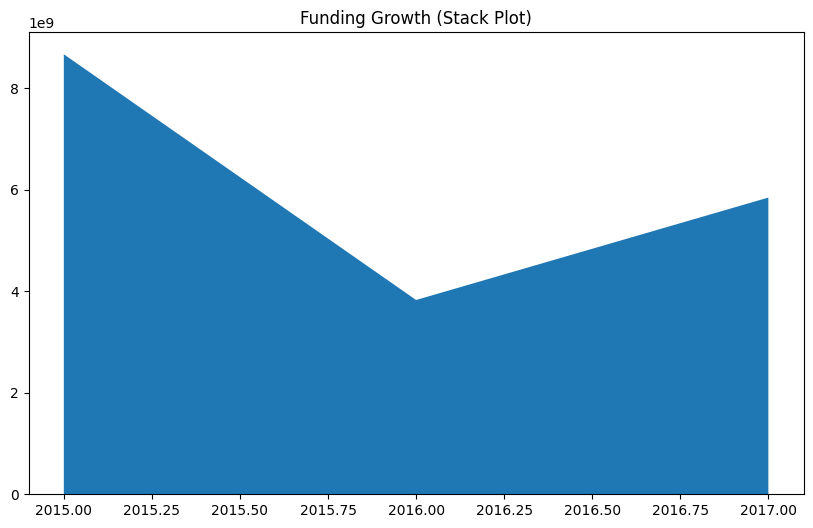

In [36]:
year = df.groupby("Year")["AmountInUSD"].sum()

plt.figure(figsize=(10,6))

plt.stackplot(
    year.index,
    year.values
)

plt.title("Funding Growth (Stack Plot)")

plt.show()

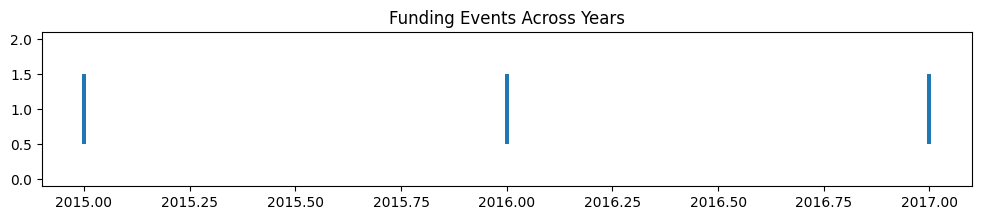

In [37]:
years = df["Year"].dropna()

plt.figure(figsize=(12,2))

plt.eventplot(years)

plt.title("Funding Events Across Years")

plt.show()